In [2]:
#Install Dependencies (run once)
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "rdkit", "--quiet"])
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "torch", "torchvision", "scikit-learn", "pandas",
    "numpy", "matplotlib", "seaborn", "Pillow", "tqdm", "--quiet"])
try:
    from rdkit import Chem
    print("rdkit OK")
except ImportError:
    print("rdkit install failed")
print("All packages ready.")

rdkit OK
All packages ready.


In [7]:
# Imports
import os, warnings, random, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Device: cuda
PyTorch: 2.10.0+cu128
CUDA available: True


In [8]:
# Configuration
DATA_PATH = '/content/naisargisharma20_gmail.com1419.tsv'

#  Paths
IMAGE_DIR       = '/content/molecular_images'
CHECKPOINT_PATH = '/content/best_resnet18.pth'
os.makedirs(IMAGE_DIR, exist_ok=True)

#  Labeling thresholds (IC50 in nM)
ACTIVE_THRESHOLD_nM   = 1000    # IC50 <= 1 uM  -> Binder (1)
INACTIVE_THRESHOLD_nM = 10000   # IC50 >  10 uM -> Non-binder (0)

# Image
IMG_SIZE = 224

# Training
BATCH_SIZE    = 32
NUM_EPOCHS    = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
DROPOUT_RATE  = 0.3
PATIENCE      = 5

# Splits
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

#  Random Forest
RF_N_ESTIMATORS       = 100
RF_FINGERPRINT_RADIUS = 2
RF_FINGERPRINT_BITS   = 2048

print('Config loaded.')
print('  DATA_PATH:       ', DATA_PATH)
print('  CHECKPOINT_PATH: ', CHECKPOINT_PATH)
print('  Active  threshold:', ACTIVE_THRESHOLD_nM, 'nM  (<= 1 uM)')
print('  Inactive threshold:', INACTIVE_THRESHOLD_nM, 'nM (> 10 uM)')
print('  Device:', DEVICE)

Config loaded.
  DATA_PATH:        /content/naisargisharma20_gmail.com1419.tsv
  CHECKPOINT_PATH:  /content/best_resnet18.pth
  Active  threshold: 1000 nM  (<= 1 uM)
  Inactive threshold: 10000 nM (> 10 uM)
  Device: cuda


In [9]:
#Loading Data
def load_bindingdb_data(filepath):
    print('Loading: ' + str(filepath))
    all_cols = pd.read_csv(filepath, sep='\t', nrows=0).columns.tolist()
    print('Columns (' + str(len(all_cols)) + '):', all_cols[:8], '...')

    smiles_col  = next((c for c in all_cols if 'smiles'  in c.lower()), None)
    ic50_col    = next((c for c in all_cols if 'ic50'    in c.lower()), None)
    target_col  = next((c for c in all_cols if 'target'  in c.lower()
                        and 'name' in c.lower()), None)
    uniprot_col = next((c for c in all_cols if 'uniprot' in c.lower()), None)

    print('SMILES col :', smiles_col)
    print('IC50 col   :', ic50_col)

    if smiles_col is None:
        raise ValueError('No SMILES column. Columns: ' + str(all_cols))
    if ic50_col is None:
        raise ValueError('No IC50 column.  Columns: ' + str(all_cols))

    cols = [c for c in [smiles_col, ic50_col, target_col, uniprot_col] if c]
    df = pd.read_csv(filepath, sep='\t', usecols=cols, low_memory=False)

    rename = {}
    if smiles_col:  rename[smiles_col]  = 'smiles'
    if ic50_col:    rename[ic50_col]    = 'ic50_nM'
    if target_col:  rename[target_col]  = 'target_name'
    if uniprot_col: rename[uniprot_col] = 'uniprot_id'
    df = df.rename(columns=rename)

    for col in ['smiles', 'ic50_nM', 'target_name', 'uniprot_id']:
        if col not in df.columns:
            df[col] = None

    print('Shape:', df.shape)
    display(df.head(3))
    return df


raw_df = load_bindingdb_data(DATA_PATH)

Loading: /content/naisargisharma20_gmail.com1419.tsv
Columns (640): ['BindingDB Reactant_set_id', 'Ligand SMILES', 'Ligand InChI', 'Ligand InChI Key', 'BindingDB MonomerID', 'BindingDB Ligand Name', 'Target Name', 'Target Source Organism According to Curator or DataSource'] ...
SMILES col : Ligand SMILES
IC50 col   : IC50 (nM)
Shape: (28809, 4)


,smiles,target_name,ic50_nM,uniprot_id
0,COc1cc(N(C)CCN(C)C)c(NC(=O)C=C)cc1Nc1nccc(n1)-...,Epidermal growth factor receptor,0.002000,Epidermal growth factor receptor
1,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,Epidermal growth factor receptor,0.003,Epidermal growth factor receptor
2,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,Epidermal growth factor receptor,0.006,Epidermal growth factor receptor


In [10]:
#Preprocessing & Labeling

def validate_smiles(s):
    try:
        mol = Chem.MolFromSmiles(str(s))
        if mol is not None:
            return Chem.MolToSmiles(mol)
    except:
        pass
    return None

def parse_ic50(v):
    try:
        return float(str(v).strip().replace(',','').replace('>','').replace('<','').replace('=',''))
    except:
        return None

def preprocess_and_label(df,
                          active_thresh=ACTIVE_THRESHOLD_nM,
                          inactive_thresh=INACTIVE_THRESHOLD_nM):
    print('=== Preprocessing ===')
    print('Step 0 - raw rows:', len(df))

    df = df.dropna(subset=['smiles', 'ic50_nM']).copy()
    print('Step 1 - drop NaN:', len(df))

    df['ic50_parsed'] = df['ic50_nM'].apply(parse_ic50)
    df = df.dropna(subset=['ic50_parsed'])
    print('Step 2 - IC50 parsed:', len(df))

    print('Step 3 - validating SMILES (may take a minute)...')
    df['canonical_smiles'] = df['smiles'].apply(validate_smiles)
    df = df.dropna(subset=['canonical_smiles'])
    print('Step 3 - valid SMILES:', len(df))

    active_mask   = df['ic50_parsed'] <= active_thresh
    inactive_mask = df['ic50_parsed'] >  inactive_thresh
    df = df[active_mask | inactive_mask].copy()
    df['label'] = (df['ic50_parsed'] <= active_thresh).astype(int)
    print('Step 4 - after thresholding:', len(df))

    df = df.drop_duplicates(subset=['canonical_smiles']).reset_index(drop=True)
    print('Step 5 - after dedup:', len(df))

    n_pos = int(df['label'].sum())
    n_neg = len(df) - n_pos
    print('Active (binders):   ', n_pos, '(' + str(round(n_pos/len(df)*100, 1)) + '%)')
    print('Inactive (non-bind):', n_neg, '(' + str(round(n_neg/len(df)*100, 1)) + '%)')

    if n_pos == 0:
        raise ValueError('No active compounds found! Lower ACTIVE_THRESHOLD_nM or check your dataset.')

    return df[['canonical_smiles', 'ic50_parsed', 'label']]


processed_df = preprocess_and_label(raw_df)
display(processed_df.head())

=== Preprocessing ===
Step 0 - raw rows: 28809
Step 1 - drop NaN: 26539
Step 2 - IC50 parsed: 26539
Step 3 - validating SMILES (may take a minute)...


[17:28:57] improperly formatted w block
[17:28:57] improperly formatted w block
[17:28:57] improperly formatted w block
[17:28:57] improperly formatted w block
[17:29:01] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:29:01] Explicit valence for atom # 25 N, 4, is greater than permitted


Step 3 - valid SMILES: 26507
Step 4 - after thresholding: 22491
Step 5 - after dedup: 12870
Active (binders):    10683 (83.0%)
Inactive (non-bind): 2187 (17.0%)


,canonical_smiles,ic50_parsed,label
0,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(O...,0.002,1
1,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,0.003,1
2,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,0.006,1
3,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.006,1
4,Cc1cc2cc(n1)-c1cnn(C)c1OCCC[C@@H](C1CC1)CN1/C(...,0.007,1


## 6. Dataset Exploration

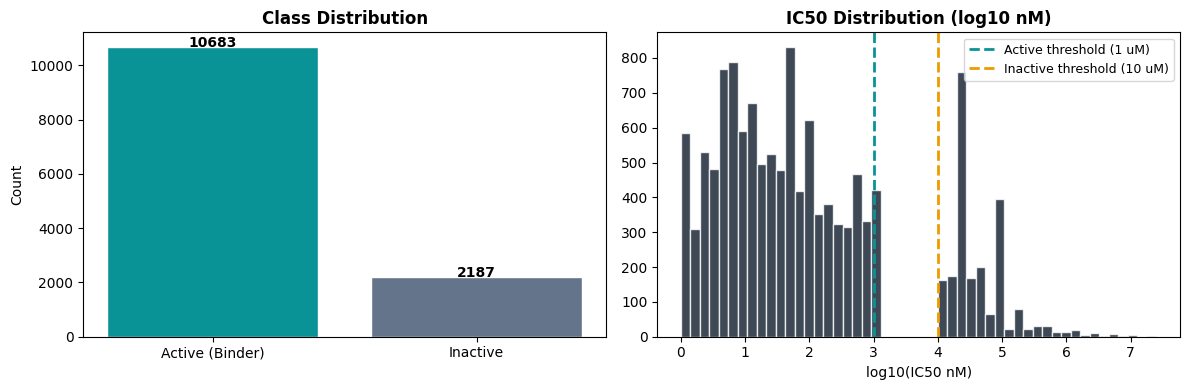

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = processed_df['label'].value_counts()
axes[0].bar(['Active (Binder)', 'Inactive'],
            [counts.get(1, 0), counts.get(0, 0)],
            color=['#0A9396', '#64748B'], edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts.get(1,0), counts.get(0,0)]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# IC50 distribution
axes[1].hist(np.log10(processed_df['ic50_parsed'] + 1), bins=50,
             color='#0D1B2A', edgecolor='white', alpha=0.8)
axes[1].axvline(np.log10(ACTIVE_THRESHOLD_nM), color='#0A9396',
                linestyle='--', linewidth=2, label='Active threshold (1 uM)')
axes[1].axvline(np.log10(INACTIVE_THRESHOLD_nM), color='#EE9B00',
                linestyle='--', linewidth=2, label='Inactive threshold (10 uM)')
axes[1].set_title('IC50 Distribution (log10 nM)', fontweight='bold')
axes[1].set_xlabel('log10(IC50 nM)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('dataset_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

Generating 12870 molecular images...


100%|██████████| 12870/12870 [02:21<00:00, 91.23it/s]


Images generated: 12870/12870
Final dataset size: 12870


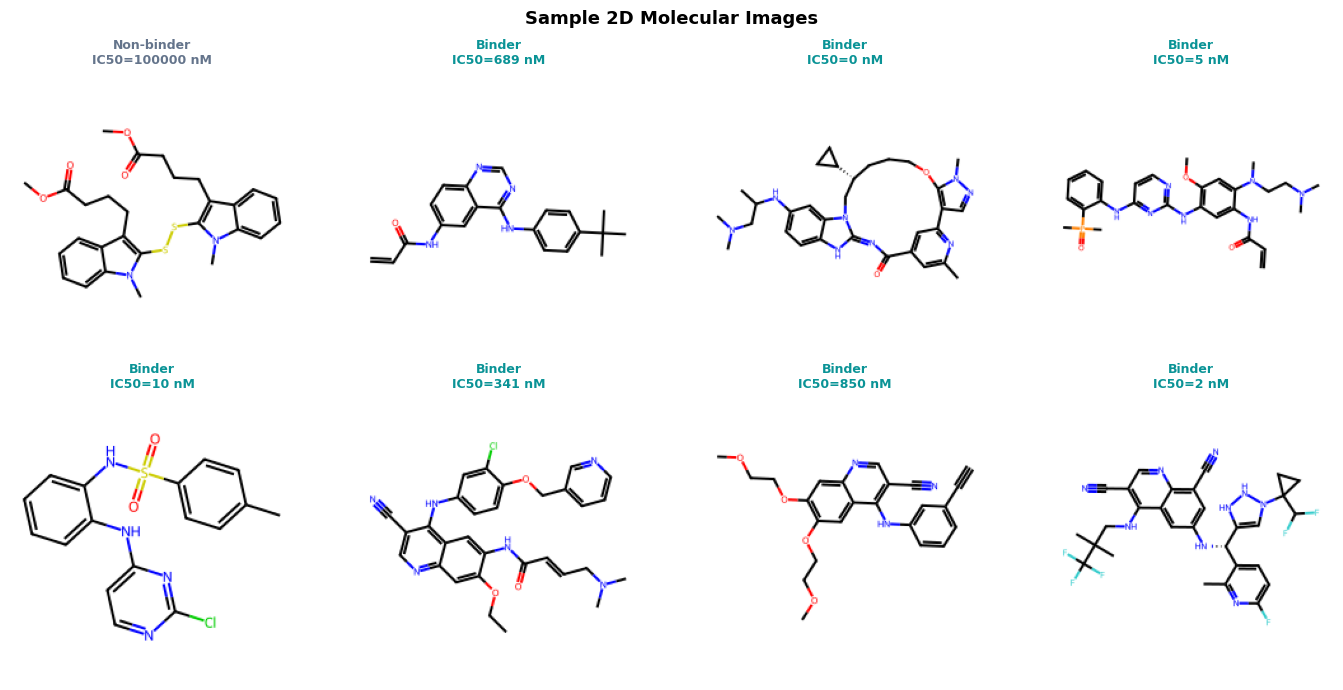

In [12]:
#SMILES to 2D Molecular Imagesdef smiles_to_image(smiles, img_size=IMG_SIZE)

    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(img_size, img_size))
        return img.convert('RGB')
    except:
        return None


def generate_images(df, image_dir=IMAGE_DIR, img_size=IMG_SIZE):
    os.makedirs(image_dir, exist_ok=True)
    image_paths, valid_idx = [], []

    print('Generating ' + str(len(df)) + ' molecular images...')
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(image_dir, 'mol_' + str(idx) + '.png')
        if not os.path.exists(img_path):
            img = smiles_to_image(row['canonical_smiles'], img_size)
            if img is not None:
                img.save(img_path)
            else:
                continue
        image_paths.append(img_path)
        valid_idx.append(idx)

    result = df.loc[valid_idx].copy()
    result['image_path'] = image_paths
    print('Images generated: ' + str(len(result)) + '/' + str(len(df)))
    return result.reset_index(drop=True)


image_df = generate_images(processed_df)
print('Final dataset size:', len(image_df))

# Show sample molecules
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
samples = image_df.sample(min(8, len(image_df)), random_state=SEED)
for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):
    img = Image.open(row['image_path'])
    ax.imshow(img)
    label_str = 'Binder' if row['label'] == 1 else 'Non-binder'
    color = '#0A9396' if row['label'] == 1 else '#64748B'
    ax.set_title(label_str + '\nIC50=' + str(round(row['ic50_parsed'])) + ' nM',
                 fontsize=9, color=color, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample 2D Molecular Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_molecules.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
#Dataset Splitting
def split_dataset(df, train_r=TRAIN_RATIO, val_r=VAL_RATIO,
                  test_r=TEST_RATIO, seed=SEED):
    train_val, test = train_test_split(
        df, test_size=test_r, stratify=df['label'], random_state=seed)
    val_frac = val_r / (train_r + val_r)
    train, val = train_test_split(
        train_val, test_size=val_frac, stratify=train_val['label'], random_state=seed)
    print('=== Split Summary ===')
    for name, s in [('Train', train), ('Val', val), ('Test', test)]:
        n, p = len(s), int(s['label'].sum())
        print(name + ': ' + str(n) + ' samples | ' + str(p) + ' active | ' +
              str(n - p) + ' inactive')
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)


train_df, val_df, test_df = split_dataset(image_df)

=== Split Summary ===
Train: 9008 samples | 7477 active | 1531 inactive
Val: 1931 samples | 1603 active | 328 inactive
Test: 1931 samples | 1603 active | 328 inactive


In [14]:
#PyTorch Dataset & DataLoader
class MolecularImageDataset(Dataset):
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    def __init__(self, df, img_size=IMG_SIZE, augment=False):
        self.df = df.reset_index(drop=True)
        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
                transforms.ToTensor(),
                transforms.Normalize(self.IMAGENET_MEAN, self.IMAGENET_STD)
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize(self.IMAGENET_MEAN, self.IMAGENET_STD)
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        return self.transform(img), torch.tensor(row['label'], dtype=torch.float32)


# Class weight for imbalance
n_pos = int(train_df['label'].sum())
n_neg = len(train_df) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(DEVICE)
print('Positive class weight:', round(pos_weight.item(), 2))
print('(' + str(n_neg) + ' negatives vs ' + str(n_pos) + ' positives)')

# num_workers=0 works on both Windows and Colab
# pin_memory=True only helps on GPU — set automatically
PIN = (DEVICE.type == 'cuda')

train_dataset = MolecularImageDataset(train_df, augment=True)
val_dataset   = MolecularImageDataset(val_df,   augment=False)
test_dataset  = MolecularImageDataset(test_df,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=PIN)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=PIN)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=PIN)

print('Train batches:', len(train_loader))
print('Val   batches:', len(val_loader))
print('Test  batches:', len(test_loader))

Positive class weight: 0.2
(1531 negatives vs 7477 positives)
Train batches: 282
Val   batches: 61
Test  batches: 61


In [15]:
#ResNet-18 Model
def build_resnet18(dropout_rate=DROPOUT_RATE, pretrained=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet18(weights=weights)
    in_features = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, 1)
    )
    return model


model = build_resnet18().to(DEVICE)
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('ResNet-18 ready')
print('Total params:    ', total)
print('Trainable params:', trainable)
print('Final layer: Dropout(' + str(DROPOUT_RATE) + ') -> Linear(512->1)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


ResNet-18 ready
Total params:     11177025
Trainable params: 11177025
Final layer: Dropout(0.3) -> Linear(512->1)


In [16]:
#Training
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_labels, all_probs = 0.0, [], []
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
    avg_loss = total_loss / len(loader.dataset)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.5
    return avg_loss, auc


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device).unsqueeze(1)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
    avg_loss = total_loss / len(loader.dataset)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.5
    return avg_loss, auc, np.array(all_labels), np.array(all_probs)


def train_model(model, train_loader, val_loader,
                num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                device=DEVICE, pos_weight=pos_weight):

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    # verbose removed — not supported in PyTorch >= 2.2
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)

    history = {'train_loss': [], 'val_loss': [],
               'train_auc':  [], 'val_auc':  []}
    best_val_auc, best_epoch, patience_count = 0.0, 0, 0
    saved_checkpoint = False

    print('=== Training ResNet-18 ===')
    print('LR:', lr, ' | WD:', weight_decay, ' | Patience:', patience)
    print('Checkpoint:', CHECKPOINT_PATH)
    print('-' * 60)
    print('Epoch | TrainLoss | ValLoss | TrainAUC | ValAUC | Status')
    print('-' * 60)

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_auc = train_one_epoch(
            model, train_loader, optimizer, criterion, device)
        vl_loss, vl_auc, _, _ = evaluate(
            model, val_loader, criterion, device)

        scheduler.step(vl_auc)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_auc'].append(tr_auc)
        history['val_auc'].append(vl_auc)

        if vl_auc > best_val_auc:
            best_val_auc, best_epoch, patience_count = vl_auc, epoch, 0
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            saved_checkpoint = True
            status = 'BEST'
        else:
            patience_count += 1
            status = str(patience_count) + '/' + str(patience)

        print(str(epoch).rjust(5) + ' |' +
              str(round(tr_loss, 4)).rjust(10) + ' |' +
              str(round(vl_loss, 4)).rjust(8) + ' |' +
              str(round(tr_auc,  4)).rjust(9) + ' |' +
              str(round(vl_auc,  4)).rjust(7) + ' | ' + status)

        if patience_count >= patience:
            print('Early stopping at epoch ' + str(epoch))
            break

    if saved_checkpoint:
        model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
        print('Best model loaded (epoch ' + str(best_epoch) +
              ', Val AUC ' + str(round(best_val_auc, 4)) + ')')
    else:
        print('WARNING: No checkpoint saved — val_auc never improved.')
        print('Using final model weights for evaluation.')

    return history


history = train_model(model, train_loader, val_loader)

=== Training ResNet-18 ===
LR: 0.0001  | WD: 0.0001  | Patience: 5
Checkpoint: /content/best_resnet18.pth
------------------------------------------------------------
Epoch | TrainLoss | ValLoss | TrainAUC | ValAUC | Status
------------------------------------------------------------
    1 |    0.1482 |  0.1425 |   0.8825 | 0.8972 | BEST
    2 |    0.1167 |  0.1081 |   0.9276 | 0.9401 | BEST
    3 |    0.0952 |  0.1208 |   0.9518 | 0.9309 | 1/5
    4 |    0.0908 |  0.1265 |   0.9567 | 0.9266 | 2/5
    5 |    0.0793 |  0.1174 |   0.9663 | 0.9308 | 3/5
    6 |    0.0736 |  0.1073 |   0.9711 | 0.9478 | BEST
    7 |    0.0662 |  0.1136 |   0.9762 | 0.9457 | 1/5
    8 |    0.0613 |  0.1041 |   0.9796 | 0.9475 | 2/5
    9 |    0.0546 |  0.1062 |   0.9835 | 0.9498 | BEST
   10 |    0.0529 |  0.1186 |   0.9844 | 0.9431 | 1/5
   11 |     0.051 |  0.1099 |   0.9855 |  0.944 | 2/5
   12 |    0.0456 |  0.1124 |   0.9881 | 0.9466 | 3/5
   13 |    0.0439 |  0.1128 |   0.9888 | 0.9523 | BEST
   14 | 

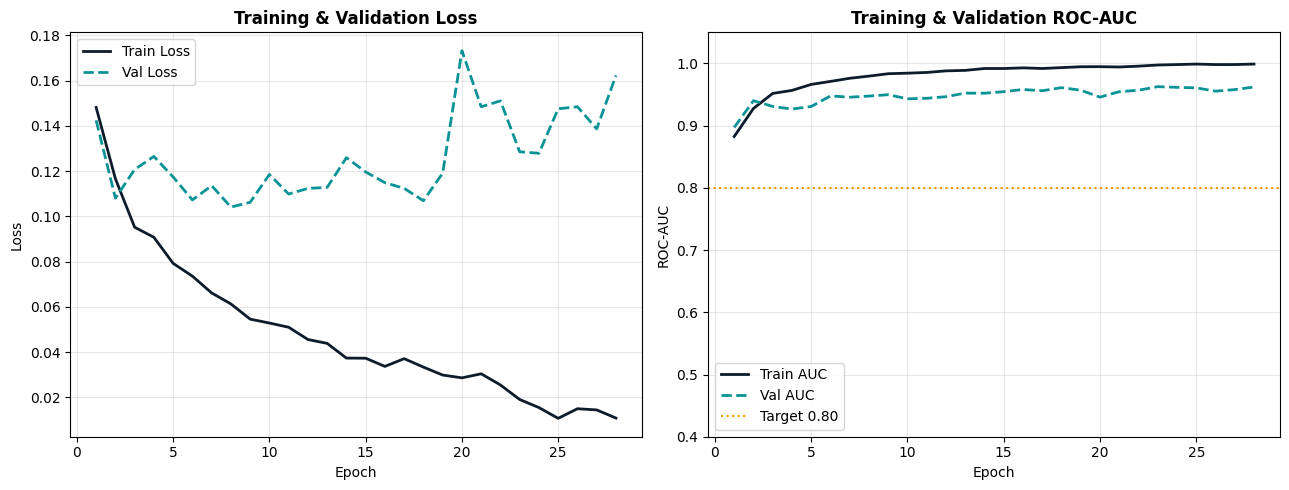

In [17]:
#Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
epochs = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs, history['train_loss'], color='#0D1B2A', linewidth=2, label='Train Loss')
ax1.plot(epochs, history['val_loss'],   color='#0A9396', linewidth=2,
         label='Val Loss', linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history['train_auc'], color='#0D1B2A', linewidth=2, label='Train AUC')
ax2.plot(epochs, history['val_auc'],   color='#0A9396', linewidth=2,
         label='Val AUC', linestyle='--')
ax2.axhline(0.8, color='#EE9B00', linestyle=':', linewidth=1.5, label='Target 0.80')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('ROC-AUC')
ax2.set_title('Training & Validation ROC-AUC', fontweight='bold')
ax2.set_ylim([0.4, 1.05]); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
#Random Forest Baseline
def smiles_to_morgan(smiles, radius=RF_FINGERPRINT_RADIUS, n_bits=RF_FINGERPRINT_BITS):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
        arr = np.zeros((n_bits,), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    except:
        return None


def make_fingerprint_matrix(df):
    fps, labels = [], []
    for _, row in df.iterrows():
        fp = smiles_to_morgan(row['canonical_smiles'])
        if fp is not None:
            fps.append(fp)
            labels.append(row['label'])
    return np.array(fps), np.array(labels)


def train_random_forest(train_df, val_df, test_df):
    print('=== Random Forest Baseline ===')
    print('Generating fingerprints...')
    X_train, y_train = make_fingerprint_matrix(train_df)
    X_test,  y_test  = make_fingerprint_matrix(test_df)
    print('Fingerprint matrix:', X_train.shape)

    rf = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS,
                                 class_weight='balanced',
                                 random_state=SEED, n_jobs=-1)

    cv = cross_val_score(rf, X_train, y_train,
                         cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                         scoring='roc_auc', n_jobs=-1)
    print('CV ROC-AUC: ' + str(round(cv.mean(), 4)) + ' +/- ' + str(round(cv.std(), 4)))

    rf.fit(X_train, y_train)
    test_probs = rf.predict_proba(X_test)[:, 1]
    test_preds = rf.predict(X_test)

    metrics = {
        'accuracy':  accuracy_score(y_test, test_preds),
        'precision': precision_score(y_test, test_preds, zero_division=0),
        'recall':    recall_score(y_test, test_preds, zero_division=0),
        'f1':        f1_score(y_test, test_preds, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, test_probs),
        'pr_auc':    average_precision_score(y_test, test_probs)
    }
    print('\nRF Test Results:')
    for k, v in metrics.items():
        print('  ' + k.ljust(12) + ': ' + str(round(v, 4)))
    return rf, test_probs, y_test, metrics


rf_model, rf_test_probs, rf_test_labels, rf_metrics = train_random_forest(
    train_df, val_df, test_df)

=== Random Forest Baseline ===
Generating fingerprints...


Streaming output truncated to the last 5000 lines.
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:03:03] DEPRECATION WARNING: please use MorganGenerator
[18:0

Fingerprint matrix: (9008, 2048)
CV ROC-AUC: 0.9803 +/- 0.0043

RF Test Results:
  accuracy    : 0.9591
  precision   : 0.9692
  recall      : 0.9819
  f1          : 0.9755
  roc_auc     : 0.9865
  pr_auc      : 0.997


In [19]:
#CNN Evaluation
def evaluate_model(model, loader, device, threshold=0.5):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    y_true  = np.array(all_labels)
    y_probs = np.array(all_probs)
    y_preds = (y_probs >= threshold).astype(int)

    metrics = {
        'accuracy':  accuracy_score(y_true, y_preds),
        'precision': precision_score(y_true, y_preds, zero_division=0),
        'recall':    recall_score(y_true, y_preds, zero_division=0),
        'f1':        f1_score(y_true, y_preds, zero_division=0),
        'roc_auc':   roc_auc_score(y_true, y_probs),
        'pr_auc':    average_precision_score(y_true, y_probs)
    }
    print('=== CNN Test Results ===')
    for k, v in metrics.items():
        print('  ' + k.ljust(12) + ': ' + str(round(v, 4)))
    return metrics, y_true, y_probs


cnn_metrics, cnn_test_labels, cnn_test_probs = evaluate_model(
    model, test_loader, DEVICE)

=== CNN Test Results ===
  accuracy    : 0.9197
  precision   : 0.9647
  recall      : 0.9376
  f1          : 0.951
  roc_auc     : 0.9605
  pr_auc      : 0.9913


## 15. Model Comparison


  RESULTS: ResNet-18 CNN vs Random Forest — EGFR DTI
Metric         ResNet-18 CNN  Random Forest  Delta
------------------------------------------------------------
Accuracy              0.9197         0.9591  DN -0.0394
Precision             0.9647         0.9692  DN -0.0045
Recall                0.9376         0.9819  DN -0.0443
F1-Score               0.951         0.9755  DN -0.0246
ROC-AUC               0.9605         0.9865  DN -0.026
PR-AUC                0.9913          0.997  DN -0.0057


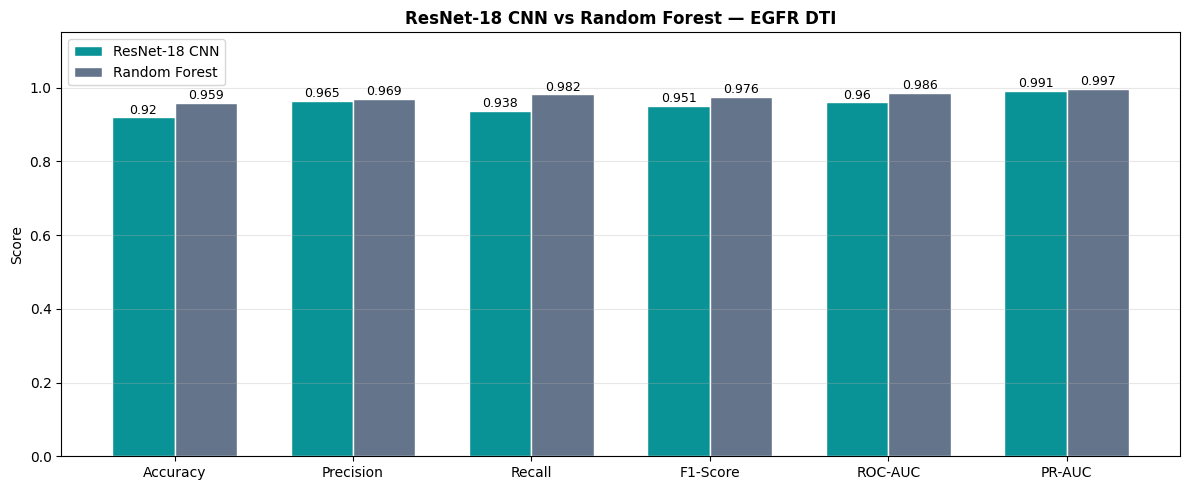

In [20]:
#Model Comparison
metric_names  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
display_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']

print('\n' + '='*60)
print('  RESULTS: ResNet-18 CNN vs Random Forest — EGFR DTI')
print('='*60)
print('Metric         ResNet-18 CNN  Random Forest  Delta')
print('-'*60)
for m, d in zip(metric_names, display_names):
    cv = cnn_metrics[m]
    rv = rf_metrics[m]
    delta = cv - rv
    arrow = 'UP' if delta > 0 else ('DN' if delta < 0 else '==')
    print(d.ljust(15) + str(round(cv, 4)).rjust(13) +
          str(round(rv, 4)).rjust(15) + '  ' + arrow +
          ' ' + str(round(delta, 4)))
print('='*60)

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(display_names))
w = 0.35
b1 = ax.bar(x - w/2, [cnn_metrics[m] for m in metric_names],
            w, label='ResNet-18 CNN', color='#0A9396', edgecolor='white')
b2 = ax.bar(x + w/2, [rf_metrics[m]  for m in metric_names],
            w, label='Random Forest', color='#64748B', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(display_names)
ax.set_ylim([0, 1.15]); ax.set_ylabel('Score')
ax.set_title('ResNet-18 CNN vs Random Forest — EGFR DTI', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            str(round(bar.get_height(), 3)), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

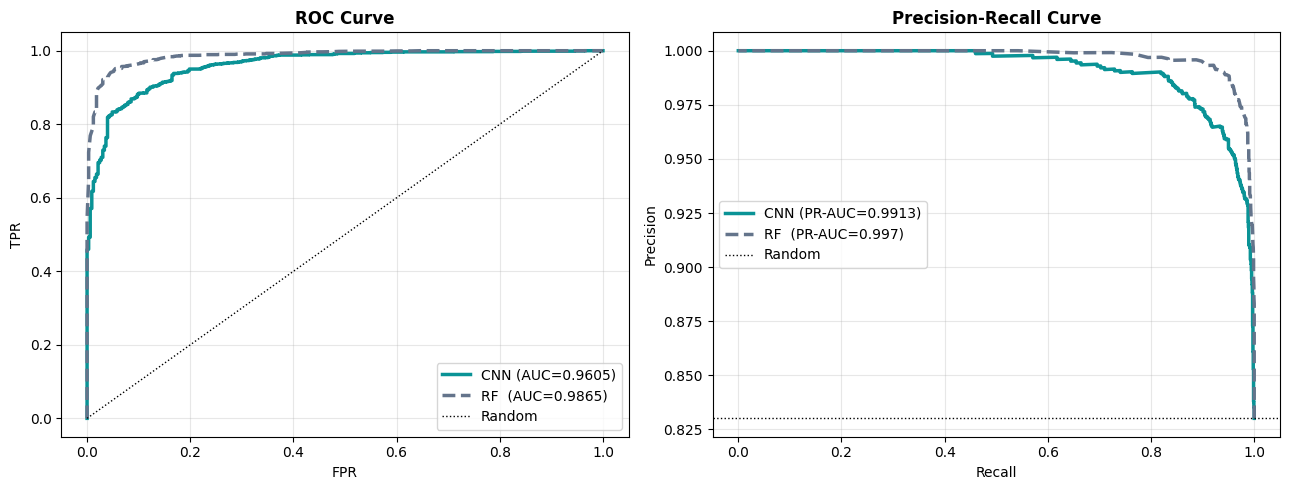

In [21]:
#ROC & Precision-Recall Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

fpr_c, tpr_c, _ = roc_curve(cnn_test_labels, cnn_test_probs)
fpr_r, tpr_r, _ = roc_curve(rf_test_labels,  rf_test_probs)
ax1.plot(fpr_c, tpr_c, color='#0A9396', lw=2.5,
         label='CNN (AUC=' + str(round(cnn_metrics['roc_auc'], 4)) + ')')
ax1.plot(fpr_r, tpr_r, color='#64748B', lw=2.5, ls='--',
         label='RF  (AUC=' + str(round(rf_metrics['roc_auc'],  4)) + ')')
ax1.plot([0,1],[0,1],'k:',lw=1,label='Random')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curve', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)

pr_c, rc_c, _ = precision_recall_curve(cnn_test_labels, cnn_test_probs)
pr_r, rc_r, _ = precision_recall_curve(rf_test_labels,  rf_test_probs)
ax2.plot(rc_c, pr_c, color='#0A9396', lw=2.5,
         label='CNN (PR-AUC=' + str(round(cnn_metrics['pr_auc'], 4)) + ')')
ax2.plot(rc_r, pr_r, color='#64748B', lw=2.5, ls='--',
         label='RF  (PR-AUC=' + str(round(rf_metrics['pr_auc'],  4)) + ')')
ax2.axhline(cnn_test_labels.mean(), color='k', ls=':', lw=1, label='Random')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

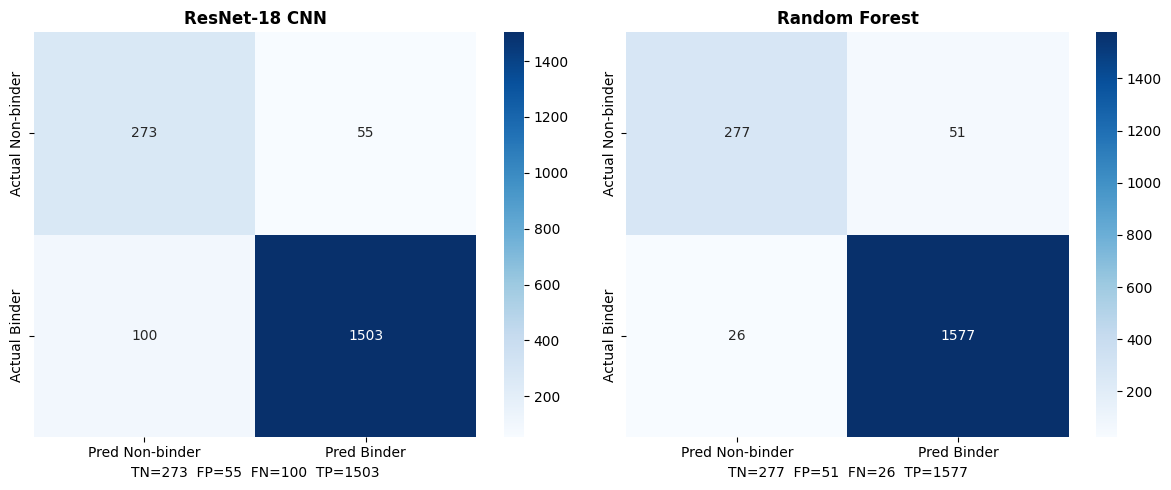

In [22]:
#Confusion Matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

def plot_cm(ax, labels, probs, title, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Non-binder', 'Pred Binder'],
                yticklabels=['Actual Non-binder', 'Actual Binder'])
    ax.set_title(title, fontweight='bold')
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel('TN=' + str(tn) + '  FP=' + str(fp) +
                  '  FN=' + str(fn) + '  TP=' + str(tp))

plot_cm(ax1, cnn_test_labels, cnn_test_probs, 'ResNet-18 CNN')
plot_cm(ax2, rf_test_labels,  rf_test_probs,  'Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

=== Error Analysis: ResNet-18 CNN ===
  TP (correct binders):     1503
  TN (correct non-binders): 273
  FP (false alarms):        55
  FN (missed binders):      100


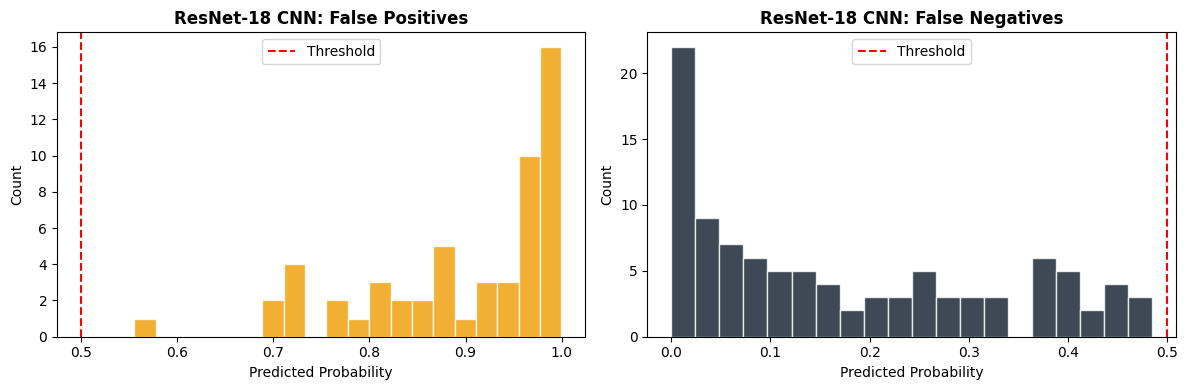

=== Error Analysis: Random Forest ===
  TP (correct binders):     1577
  TN (correct non-binders): 277
  FP (false alarms):        51
  FN (missed binders):      26


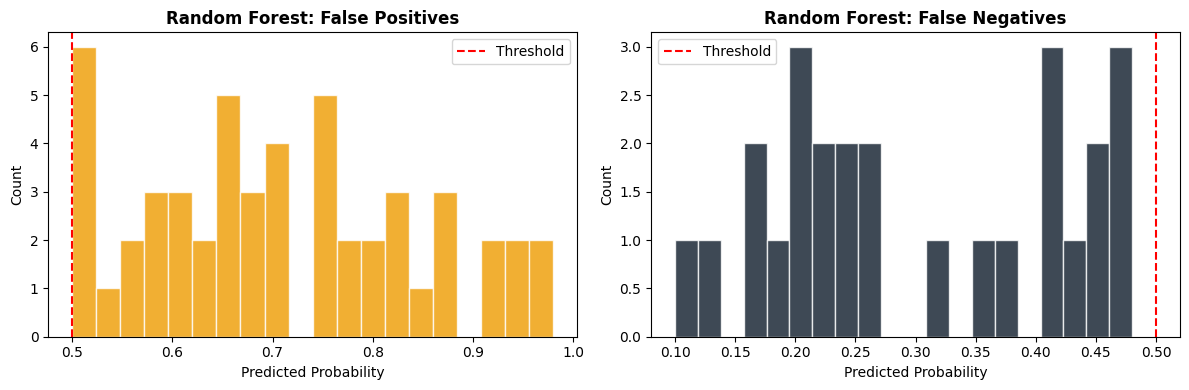

In [23]:
#Error Analysis
def error_analysis(probs, labels, model_name, threshold=0.5):
    preds  = (probs >= threshold).astype(int)
    tp = int(((preds==1)&(labels==1)).sum())
    tn = int(((preds==0)&(labels==0)).sum())
    fp = int(((preds==1)&(labels==0)).sum())
    fn = int(((preds==0)&(labels==1)).sum())
    fp_mask = (preds==1)&(labels==0)
    fn_mask = (preds==0)&(labels==1)

    print('=== Error Analysis: ' + model_name + ' ===')
    print('  TP (correct binders):    ', tp)
    print('  TN (correct non-binders):', tn)
    print('  FP (false alarms):       ', fp)
    print('  FN (missed binders):     ', fn)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(probs[fp_mask], bins=20, color='#EE9B00', edgecolor='white', alpha=0.8)
    axes[0].set_title(model_name + ': False Positives', fontweight='bold')
    axes[0].set_xlabel('Predicted Probability'); axes[0].set_ylabel('Count')
    axes[0].axvline(threshold, color='red', ls='--', label='Threshold')
    axes[0].legend()

    axes[1].hist(probs[fn_mask], bins=20, color='#0D1B2A', edgecolor='white', alpha=0.8)
    axes[1].set_title(model_name + ': False Negatives', fontweight='bold')
    axes[1].set_xlabel('Predicted Probability'); axes[1].set_ylabel('Count')
    axes[1].axvline(threshold, color='red', ls='--', label='Threshold')
    axes[1].legend()

    plt.tight_layout()
    fname = 'error_analysis_' + model_name.replace(' ', '_') + '.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

error_analysis(cnn_test_probs, cnn_test_labels, 'ResNet-18 CNN')
error_analysis(rf_test_probs,  rf_test_labels,  'Random Forest')

In [24]:
#Save All Results
import os
# Results CSV
results_df = pd.DataFrame({
    'Metric':       display_names,
    'ResNet18_CNN': [cnn_metrics[m] for m in metric_names],
    'RandomForest': [rf_metrics[m]  for m in metric_names]
})
results_df.to_csv('final_results.csv', index=False)
print('Saved: final_results.csv')

# Final CNN model
final_pth = os.path.join(os.path.dirname(CHECKPOINT_PATH), 'resnet18_egfr_final.pth')
torch.save(model.state_dict(), final_pth)
print('Saved: ' + final_pth)

# Random Forest model
rf_pkl = os.path.join(os.path.dirname(CHECKPOINT_PATH), 'random_forest_egfr.pkl')
with open(rf_pkl, 'wb') as f:
    pickle.dump(rf_model, f)
print('Saved: ' + rf_pkl)

print('\n=== DONE ===')
print('Files saved:')
for fname in ['final_results.csv', final_pth, rf_pkl,
              'training_curves.png', 'model_comparison.png',
              'roc_pr_curves.png', 'confusion_matrices.png']:
    exists = os.path.exists(fname)
    print('  ' + ('OK' if exists else 'MISSING') + '  ' + fname)

Saved: final_results.csv
Saved: /content/resnet18_egfr_final.pth
Saved: /content/random_forest_egfr.pkl

=== DONE ===
Files saved:
  OK  final_results.csv
  OK  /content/resnet18_egfr_final.pth
  OK  /content/random_forest_egfr.pkl
  OK  training_curves.png
  OK  model_comparison.png
  OK  roc_pr_curves.png
  OK  confusion_matrices.png
